# 10 — Évaluation finale et comparaison des modèles

**Objectif** : fusionner les résultats des 5 algorithmes (Logistic Regression, KNN, Decision Tree, Random Forest, SVM), comparer leurs performances sur les deux expériences (A : 9 features, B1 : 5 features), et sélectionner le meilleur modèle selon le F1-score (critère prioritaire) et le Recall (critère secondaire, important en contexte médical).

**Rappel méthodologique** : l'Expérience A contient un data leakage total (les features ont servi à construire le label) — c'est un test de cohérence du pipeline, pas un cas réel de prédiction. L'Expérience B1 retire les variables à poids fort du label — c'est le résultat le plus représentatif d'une vraie capacité de généralisation, et celui qui doit guider la conclusion médicale du projet.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.metrics import roc_curve, auc, RocCurveDisplay

os.makedirs('../figures', exist_ok=True)

## 1. Fusion des résultats de tous les modèles

In [3]:
result_files = {
    'Logistic Regression': '../data/processed/results_logreg.csv',
    'KNN': '../data/processed/results_knn.csv',
    'Decision Tree': '../data/processed/results_dt.csv',
    'Random Forest': '../data/processed/results_rf.csv',
    'SVM': '../data/processed/results_svm.csv',
}

all_results = []
for algo_name, path in result_files.items():
    if os.path.exists(path):
        df_temp = pd.read_csv(path)
        df_temp['Algorithme'] = algo_name
        all_results.append(df_temp)
    else:
        print(f"⚠️ Fichier manquant: {path}")

df_all = pd.concat(all_results, ignore_index=True)

# Extraire Expérience (A / B1) et Type (baseline / optimisé) depuis la colonne 'Modèle'
df_all['Expérience'] = df_all['Modèle'].apply(lambda x: 'A' if 'Exp A' in x else 'B1')
df_all['Type'] = df_all['Modèle'].apply(lambda x: 'Optimisé' if 'optimisé' in x else 'Baseline')

df_all = df_all[['Algorithme', 'Expérience', 'Type', 'Accuracy', 'Precision', 'Recall', 'F1-score']]
df_all

,Algorithme,Expérience,Type,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,A,Baseline,0.839514,0.760327,0.641454,0.695850
1,Logistic Regression,A,Optimisé,0.835906,0.667759,0.849125,0.747600
2,Logistic Regression,B1,Baseline,0.823870,0.735078,0.601301,0.661494
3,Logistic Regression,B1,Optimisé,0.823650,0.649495,0.833784,0.730191
4,KNN,A,Baseline,0.933377,0.921167,0.839020,0.878176
5,KNN,A,Optimisé,0.938837,0.945269,0.834617,0.886504
6,KNN,B1,Baseline,0.835257,0.724895,0.683942,0.703823
7,KNN,B1,Optimisé,0.841451,0.741077,0.685543,0.712229
8,Decision Tree,A,Baseline,0.998836,0.998531,0.997399,0.997964
9,Decision Tree,A,Optimisé,0.999227,0.999199,0.998099,0.998649


## 2. Tableau comparatif — modèles optimisés uniquement, triés par F1-score

In [4]:
df_optimized = df_all[df_all['Type'] == 'Optimisé'].copy()

print("=" * 70)
print("EXPÉRIENCE A (9 features — sanity check, data leakage total)")
print("=" * 70)
df_exp_A = df_optimized[df_optimized['Expérience'] == 'A'].sort_values('F1-score', ascending=False)
display(df_exp_A.reset_index(drop=True))

print("\n" + "=" * 70)
print("EXPÉRIENCE B1 (5 features — problème réaliste)")
print("=" * 70)
df_exp_B1 = df_optimized[df_optimized['Expérience'] == 'B1'].sort_values('F1-score', ascending=False)
display(df_exp_B1.reset_index(drop=True))

EXPÉRIENCE A (9 features — sanity check, data leakage total)


,Algorithme,Expérience,Type,Accuracy,Precision,Recall,F1-score
0,Decision Tree,A,Optimisé,0.999227,0.999199,0.998099,0.998649
1,Random Forest,A,Optimisé,0.998836,0.998864,0.997065,0.997964
2,SVM,A,Optimisé,0.943953,0.915469,0.885976,0.900481
3,KNN,A,Optimisé,0.938837,0.945269,0.834617,0.886504
4,Logistic Regression,A,Optimisé,0.835906,0.667759,0.849125,0.747600



EXPÉRIENCE B1 (5 features — problème réaliste)


,Algorithme,Expérience,Type,Accuracy,Precision,Recall,F1-score
0,Decision Tree,B1,Optimisé,0.835972,0.684035,0.793330,0.734640
1,Logistic Regression,B1,Optimisé,0.823650,0.649495,0.833784,0.730191
2,Random Forest,B1,Optimisé,0.847426,0.759586,0.683108,0.719320
3,SVM,B1,Optimisé,0.845594,0.761952,0.669735,0.712873
4,KNN,B1,Optimisé,0.841451,0.741077,0.685543,0.712229


## 3. Visualisation comparative — barres groupées par métrique

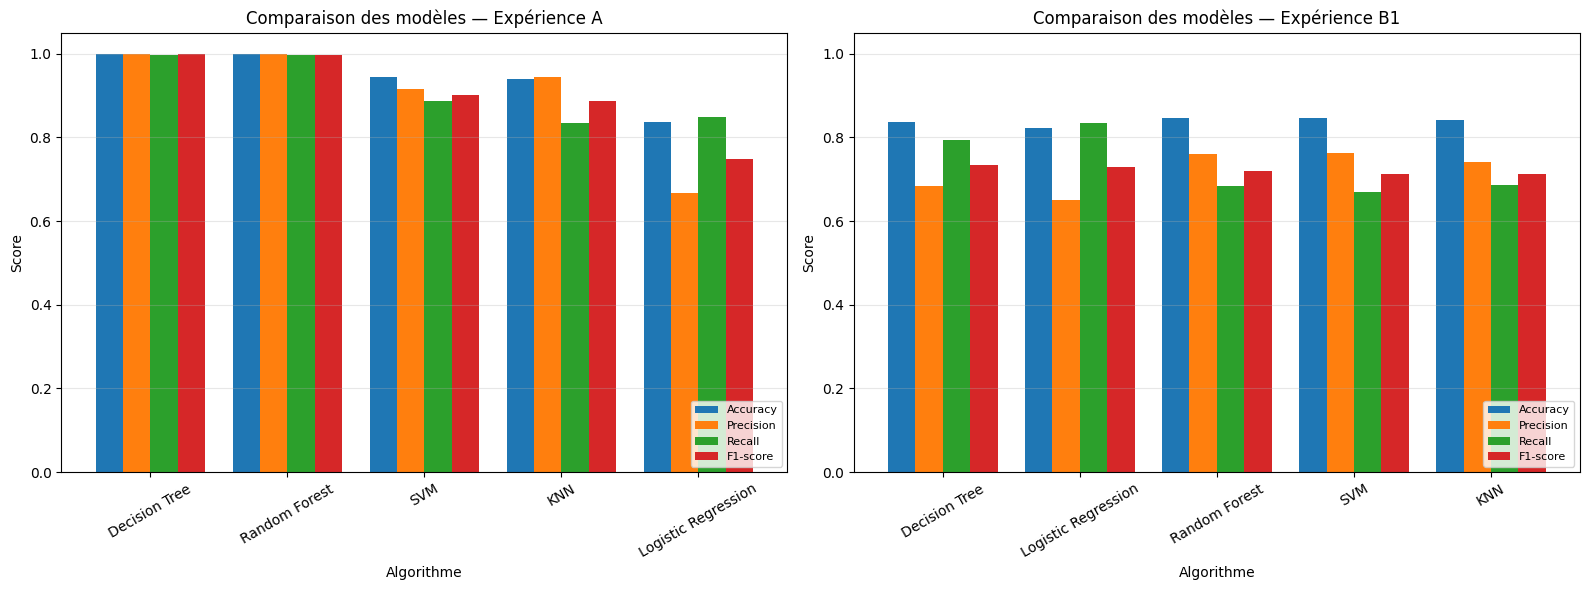

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']

for ax, (exp, df_exp) in zip(axes, [('A', df_exp_A), ('B1', df_exp_B1)]):
    df_plot = df_exp.set_index('Algorithme')[metrics]
    df_plot.plot(kind='bar', ax=ax, width=0.8)
    ax.set_title(f'Comparaison des modèles — Expérience {exp}')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.legend(loc='lower right', fontsize=8)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/comparaison_metriques_globale.png', dpi=150)
plt.show()

## 4. Courbes ROC / AUC

La courbe ROC trace le taux de vrais positifs contre le taux de faux positifs à différents seuils de décision. L'AUC (Area Under Curve) résume cette courbe en un seul chiffre — plus proche de 1, meilleure est la capacité du modèle à distinguer les deux classes, indépendamment du seuil choisi.

In [6]:
# Chargement des données de test et des modèles sauvegardés
X_test_A  = pd.read_csv('../data/processed/X_test_A.csv')
y_test_A  = pd.read_csv('../data/processed/y_test_A.csv').squeeze()
X_test_B1 = pd.read_csv('../data/processed/X_test_B1.csv')
y_test_B1 = pd.read_csv('../data/processed/y_test_B1.csv').squeeze()

model_files = {
    'Logistic Regression': ('logreg_A_best.pkl', 'logreg_B1_best.pkl'),
    'KNN': ('knn_A_best.pkl', 'knn_B1_best.pkl'),
    'Decision Tree': ('dt_A_best.pkl', 'dt_B1_best.pkl'),
    'Random Forest': ('rf_A_best.pkl', 'rf_B1_best.pkl'),
    'SVM': ('svm_A_best.pkl', 'svm_B1_best.pkl'),
}

models_A, models_B1 = {}, {}
for name, (file_A, file_B1) in model_files.items():
    path_A, path_B1 = f'../models/{file_A}', f'../models/{file_B1}'
    if os.path.exists(path_A):
        models_A[name] = joblib.load(path_A)
    if os.path.exists(path_B1):
        models_B1[name] = joblib.load(path_B1)

print("Modèles chargés (Exp A):", list(models_A.keys()))
print("Modèles chargés (Exp B1):", list(models_B1.keys()))

Modèles chargés (Exp A): ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'SVM']
Modèles chargés (Exp B1): ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'SVM']


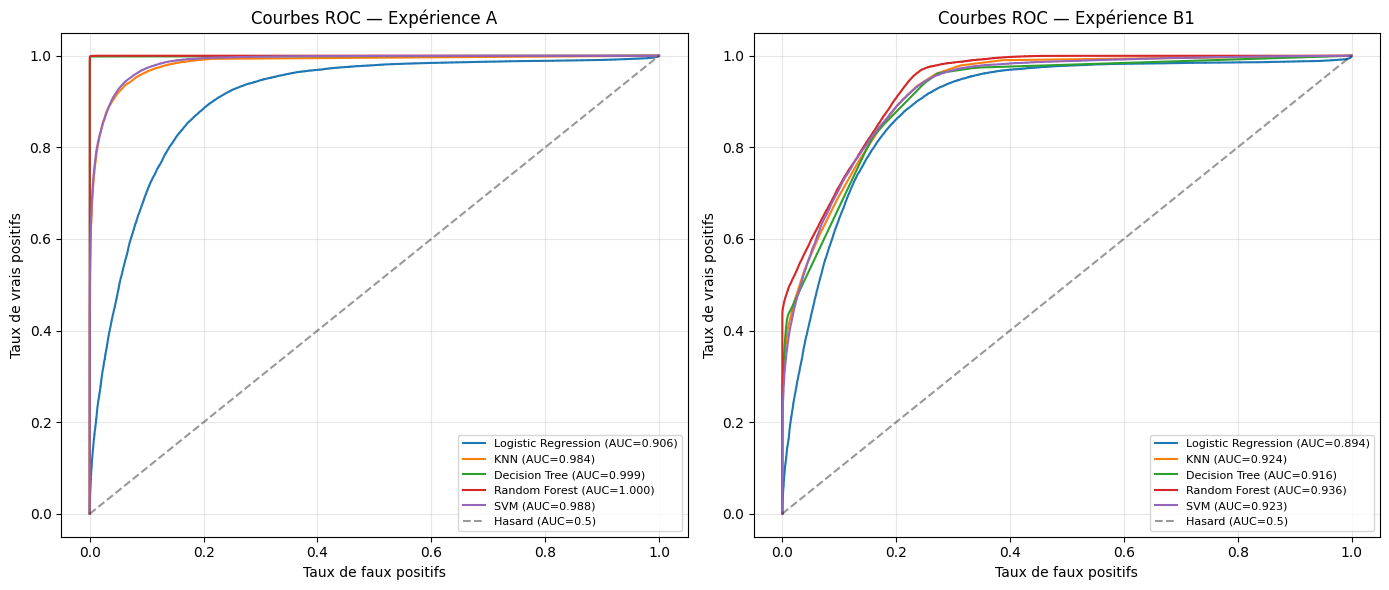

In [7]:
def get_scores(model, X):
    """Retourne un score continu pour tracer la ROC (proba si dispo, sinon decision_function)."""
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    elif hasattr(model, 'decision_function'):
        return model.decision_function(X)
    else:
        return model.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (exp_label, models_dict, X_test, y_test) in zip(
    axes,
    [('A', models_A, X_test_A, y_test_A), ('B1', models_B1, X_test_B1, y_test_B1)]
):
    for name, model in models_dict.items():
        scores = get_scores(model, X_test)
        fpr, tpr, _ = roc_curve(y_test, scores)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Hasard (AUC=0.5)')
    ax.set_title(f'Courbes ROC — Expérience {exp_label}')
    ax.set_xlabel('Taux de faux positifs')
    ax.set_ylabel('Taux de vrais positifs')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/courbes_roc_comparaison.png', dpi=150)
plt.show()

## 5. Sélection du meilleur modèle

Critère de sélection (défini dès le plan initial du projet) : **F1-score en priorité**, **Recall en critère secondaire** (en contexte médical, manquer une vraie anomalie — faux négatif — est plus grave qu'une fausse alerte).

In [12]:
best_A = df_exp_A.sort_values(['F1-score', 'Recall'], ascending=False).iloc[0]
best_B1 = df_exp_B1.sort_values(['F1-score', 'Recall'], ascending=False).iloc[0]

print("🏆 Meilleur modèle — Expérience A (sanity check) :")
print(f"   {best_A['Algorithme']} — F1={best_A['F1-score']:.4f}, Recall={best_A['Recall']:.4f}, "
      f"Precision={best_A['Precision']:.4f}, Accuracy={best_A['Accuracy']:.4f}")

print("\n🏆 Meilleur modèle — Expérience B1 (problème réaliste, résultat principal) :")
print(f"   {best_B1['Algorithme']} — F1={best_B1['F1-score']:.4f}, Recall={best_B1['Recall']:.4f}, "
      f"Precision={best_B1['Precision']:.4f}, Accuracy={best_B1['Accuracy']:.4f}")

🏆 Meilleur modèle — Expérience A (sanity check) :
   Decision Tree — F1=0.9986, Recall=0.9981, Precision=0.9992, Accuracy=0.9992

🏆 Meilleur modèle — Expérience B1 (problème réaliste, résultat principal) :
   Decision Tree — F1=0.7346, Recall=0.7933, Precision=0.6840, Accuracy=0.8360


## 6. Écart Expérience A vs B1 — preuve quantitative du data leakage

In [13]:
comparison_AB = df_exp_A[['Algorithme', 'F1-score']].merge(
    df_exp_B1[['Algorithme', 'F1-score']],
    on='Algorithme', suffixes=(' (Exp A)', ' (Exp B1)')
)
comparison_AB['Écart F1 (A - B1)'] = (
    comparison_AB['F1-score (Exp A)'] - comparison_AB['F1-score (Exp B1)']
)
comparison_AB = comparison_AB.sort_values('Écart F1 (A - B1)', ascending=False)
comparison_AB

,Algorithme,F1-score (Exp A),F1-score (Exp B1),Écart F1 (A - B1)
1,Random Forest,0.997964,0.719320,0.278644
0,Decision Tree,0.998649,0.734640,0.264009
2,SVM,0.900481,0.712873,0.187608
3,KNN,0.886504,0.712229,0.174275
4,Logistic Regression,0.747600,0.730191,0.017409


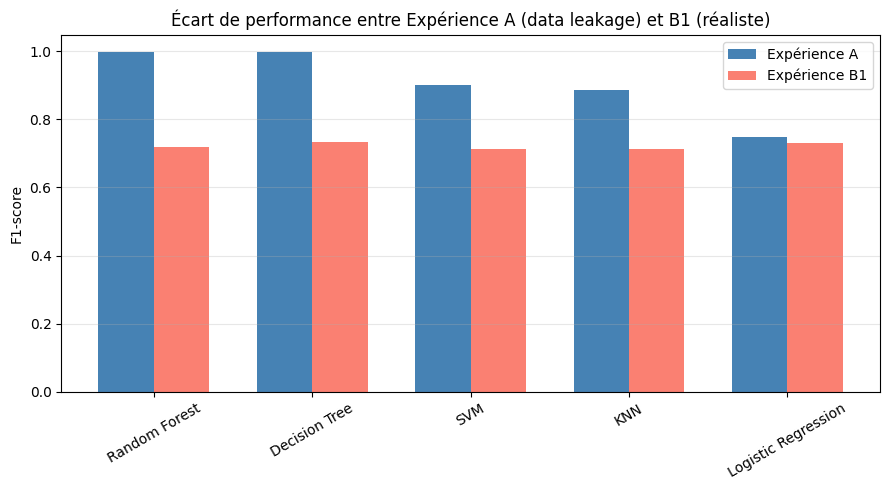

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(comparison_AB))
width = 0.35

ax.bar(x - width/2, comparison_AB['F1-score (Exp A)'], width, label='Expérience A', color='steelblue')
ax.bar(x + width/2, comparison_AB['F1-score (Exp B1)'], width, label='Expérience B1', color='salmon')

ax.set_xticks(x)
ax.set_xticklabels(comparison_AB['Algorithme'], rotation=30)
ax.set_ylabel('F1-score')
ax.set_title('Écart de performance entre Expérience A (data leakage) et B1 (réaliste)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/ecart_A_vs_B1.png', dpi=150)
plt.show()

## 7. Sauvegarde du tableau final

In [15]:
df_all.to_csv('../data/processed/results_all_models.csv', index=False)
comparison_AB.to_csv('../data/processed/comparison_A_vs_B1.csv', index=False)
print("✅ Tableaux finaux sauvegardés")

✅ Tableaux finaux sauvegardés
